# Glorat_And_He_Weight_Initialization

## Table of Content
```markdown
1. Custom Glorat
  - Model Build
  - Weight Update
  - Model Compile
  - Model Training
  - Plot Decision Boundary
2. Inbuild Glorat Normal
  - Model Build
  - Model Compile
  - Model Training
  - Plot Decision Boundary
3. Inbuild Glorat Uniform
  - Model Build
  - Model Compile
  - Model Training
  - Plot Decision Boundary
3. Inbuild He Normal
  - Model Build
  - Model Compile
  - Model Training
  - Plot Decision Boundary
4. Inbuild He Uniform
  - Model Build
  - Model Compile
  - Model Training
  - Plot Decision Boundary

```

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [3]:
from keras import Sequential
from keras.layers import Dense, Input

from keras.optimizers import Adam
from keras.activations import relu, tanh, sigmoid
from keras.initializers import GlorotUniform, HeUniform, GlorotNormal, HeNormal

from keras.losses import BinaryCrossentropy

from keras import regularizers

In [4]:
import random

# Make Dataset

In [5]:
X, y = make_moons(n_samples=100, noise=0.1, random_state=0)

## Plot Datatset

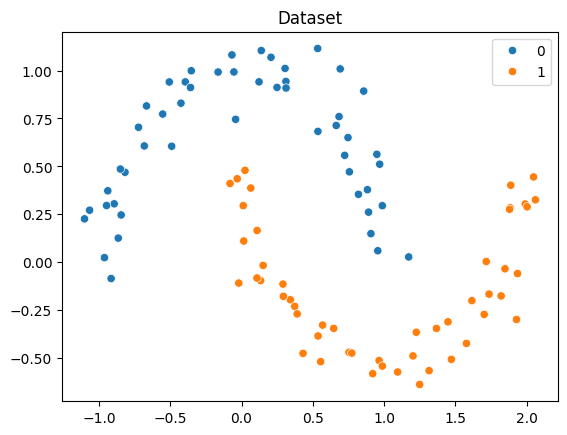

In [6]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
plt.title('Dataset')
plt.show()

# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Default Model

## Model Build

In [8]:
model1 = Sequential()
model1.add(Input(shape=(2,)))
model1.add(Dense(10, activation=relu))
model1.add(Dense(10, activation=relu))
model1.add(Dense(1, activation='sigmoid'))

In [9]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Compile

In [10]:
model1.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

## Model Training

In [11]:
model1.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


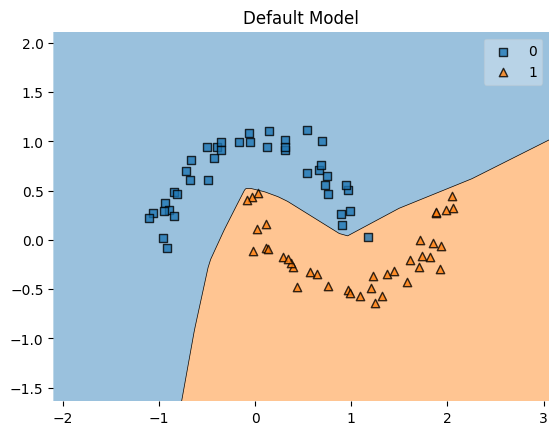

In [12]:
plot_decision_regions(X_train, y_train, clf=model1)
plt.title('Default Model')
plt.show()

# Custom Glorat

| Activation  | Xavier Recommended? |
| ----------- | ------------------- |
| Sigmoid     | ✔️ Yes              |
| Tanh        | ✔️ Yes              |
| Softsign    | ✔️ Yes              |
| Linear      | ✔️ Yes              |
| ReLU family | ❌ No (use He)       |


## Model Build

In [13]:
model2 = Sequential()
model2.add(Input(shape=(2,)))
model2.add(Dense(10, activation=sigmoid))
model2.add(Dense(10, activation=tanh))
model2.add(Dense(1, activation='sigmoid'))

In [14]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Weight Updates

In [15]:
model2.get_weights()

[array([[-0.02552348,  0.14586806, -0.237587  ,  0.10997325,  0.44144493,
         -0.5097059 ,  0.55008143, -0.22304347, -0.23067912, -0.43329725],
        [-0.35857746,  0.06678772, -0.47285712, -0.15038824, -0.14079422,
         -0.37009922, -0.04969954,  0.59357816,  0.42210132,  0.5534126 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.07839423, -0.09265608, -0.31819355, -0.13028246,  0.33181214,
          0.35312015, -0.33575273, -0.18968958, -0.42656255, -0.27604902],
        [-0.5060048 ,  0.21554232, -0.4890782 ,  0.46636486, -0.29727337,
         -0.5162736 , -0.07023466, -0.35017413, -0.47889906,  0.01412421],
        [ 0.08426195, -0.42057866, -0.24825692, -0.22948709,  0.1344983 ,
         -0.5093097 ,  0.16491926, -0.32242864, -0.03699565,  0.06110305],
        [ 0.01732838, -0.38403904, -0.227662  ,  0.34924942, -0.34237844,
          0.1127665 , -0.11665201,  0.4983313 ,  0.26610255,  0.21931094],
        [-0.24744

In [16]:
weights2 = model2.get_weights()

weights2[0] = np.random.randn(2, 10) * np.sqrt(1 / 2)
weights2[1] = np.zeros(weights2[1].shape[0])

weights2[2] = np.random.randn(10, 10) * np.sqrt(1 / 10)
weights2[3] = np.zeros(weights2[3].shape[0])

weights2[4] = np.random.randn(10, 1) * np.sqrt(1 / 10)
weights2[5] = np.zeros(weights2[5].shape[0])

model2.set_weights(weights2)
model2.get_weights()

[array([[-0.10899574, -0.6634487 ,  0.3635146 , -0.1078725 ,  0.57358223,
          0.42991063, -0.04200774, -0.02980834, -0.25785986,  0.46369907],
        [-0.40930963, -0.3699948 , -1.654951  ,  0.5588269 , -0.06514312,
         -0.38169694,  0.9982617 ,  0.36773542, -0.5027104 ,  0.02518619]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.41683117, -0.11363073, -0.25452274,  0.02420723, -0.652879  ,
          0.07988341,  0.3039751 , -0.20157792,  0.10122118,  0.09406497],
        [ 0.08984632,  0.39895394, -0.7143027 , -0.4948263 ,  0.20787506,
         -0.13047922, -0.06666251,  0.06727346, -0.17102149,  0.04465505],
        [-0.21334709, -0.01458058,  0.19752589,  0.3273725 , -0.38415733,
          0.0411359 ,  0.24731052, -0.33682394, -0.5148598 ,  0.05826292],
        [ 0.40256113, -0.35243714,  0.37608534,  0.7586685 ,  0.44406345,
         -0.41353202,  0.13820028, -0.38100758, -0.16251113, -0.00532214],
        [ 0.08204

## Model Training

In [17]:
model2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [18]:
model2.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


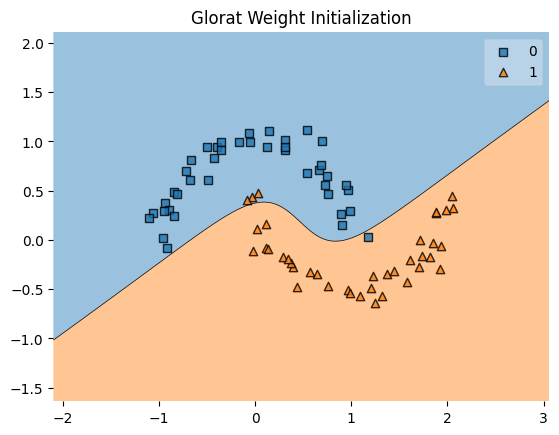

In [19]:
plot_decision_regions(X_train, y_train, clf=model2)
plt.title('Glorat Weight Initialization')
plt.show()

# Inbuild Glorat Normal

## model build

In [20]:
model3 = Sequential()
model3.add(Input(shape=(2,)))
model3.add(Dense(10, activation=sigmoid, kernel_initializer=GlorotNormal()))
model3.add(Dense(10, activation=tanh, kernel_initializer=GlorotNormal()))
model3.add(Dense(1, activation='sigmoid'))

In [21]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Weight Updates

In [22]:
model3.get_weights()

[array([[-0.07563944, -0.54794186,  0.38611287,  0.13875164, -0.64561105,
         -0.24645828, -0.6660494 , -0.19593264, -0.14567941, -0.6200612 ],
        [ 0.2824665 ,  0.34558505, -0.7855245 , -0.35172087, -0.67512167,
          0.04575165, -0.6709412 ,  0.26738214, -0.5295255 , -0.10809861]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-2.99989134e-01,  6.59043491e-02,  5.40792197e-02,
         -2.06668481e-01, -4.62687969e-01,  1.01944752e-01,
          2.54507124e-01, -1.12424139e-02,  2.11996302e-01,
         -5.58104396e-01],
        [ 6.45702362e-01, -4.06682678e-02,  2.52188265e-01,
          9.98745188e-02,  5.84854260e-02, -6.09155178e-01,
          1.01035193e-01, -6.15106702e-01,  5.64377867e-02,
         -1.74618632e-01],
        [ 4.33340490e-01,  8.91487077e-02, -2.72683501e-02,
         -9.98860598e-02, -4.23029065e-01, -2.90241659e-01,
         -3.86103988e-01,  4.52874452e-01, -3.82461399e-01,
          1.1501335

## Model training

In [23]:
model3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [24]:
model3.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


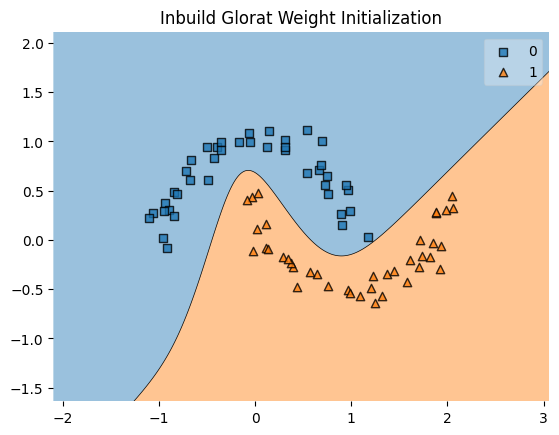

In [25]:
plot_decision_regions(X_train, y_train, clf=model3)
plt.title('Inbuild Glorat Weight Initialization')
plt.show()

# Inbuild Glorat Uniform

## Model Build

In [26]:
model4 = Sequential()
model4.add(Input(shape=(2,)))
model4.add(Dense(10, activation=sigmoid, kernel_initializer=GlorotUniform()))
model4.add(Dense(10, activation=sigmoid, kernel_initializer=GlorotUniform()))
model4.add(Dense(1, activation='sigmoid'))

## Model Training

In [27]:
model4.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [28]:
model4.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


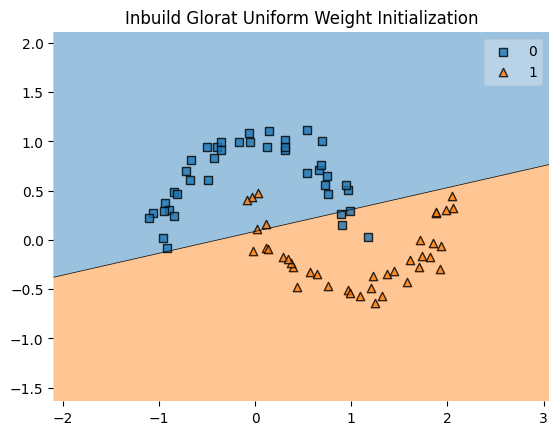

In [29]:
plot_decision_regions(X_train, y_train, clf=model4)
plt.title('Inbuild Glorat Uniform Weight Initialization')
plt.show()

# Inbuild `He` Normal

In [30]:
model5 = Sequential()
model5.add(Input(shape=(2,)))
model5.add(Dense(10, activation=relu, kernel_initializer=HeNormal()))
model5.add(Dense(10, activation=relu, kernel_initializer=HeNormal()))
model5.add(Dense(1, activation='sigmoid'))

In [31]:
model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [32]:
model5.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [33]:
model5.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


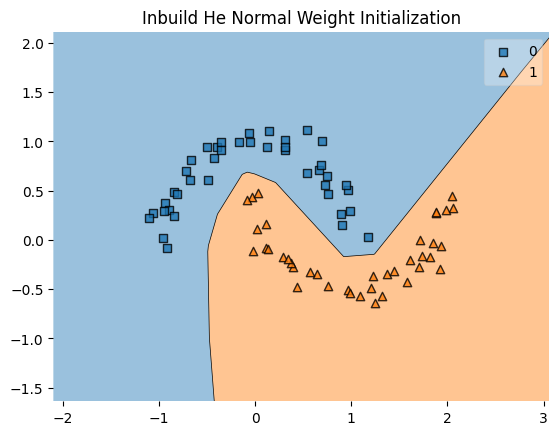

In [34]:
plot_decision_regions(X_train, y_train, clf=model5)
plt.title('Inbuild He Normal Weight Initialization')
plt.show()

# Inbuild `He` Uniform

## Model Build

In [35]:
model6 = Sequential()
model6.add(Input(shape=(2,)))
model6.add(Dense(10, activation=relu, kernel_initializer=HeUniform()))
model6.add(Dense(10, activation=relu, kernel_initializer=HeUniform()))
model6.add(Dense(1, activation='sigmoid'))

In [36]:
model6.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [37]:
model6.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [38]:
model6.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


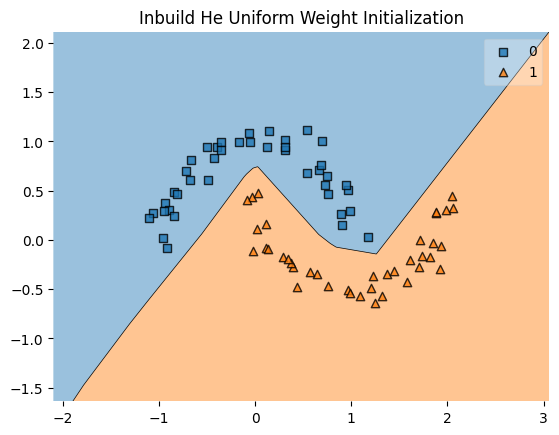

In [39]:
plot_decision_regions(X_train, y_train, clf=model6)
plt.title('Inbuild He Uniform Weight Initialization')
plt.show()